<a href="https://colab.research.google.com/github/devarahaasan/forest-cover-classification/blob/main/project3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

file_path = r"/content/cleaned_data (1).csv"
data = pd.read_csv(file_path)
data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Distance_to_Hydrology,Average_Hillshade,Hydro_Road_Total,Hydro_Fire_Total,Road_Fire_Total,Hydro_Road_Diff,Elevation_Vertical_Hydro,Slope_Elevation_Interaction,Hillshade_9am_Noon_Diff,Hillshade_Noon_3pm_Diff
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,258.000000,200.333333,768.0,6537.0,6789.0,252.0,2596.0,7788.0,-11.0,84.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,212.084889,202.000000,602.0,6437.0,6615.0,178.0,2596.0,5180.0,-15.0,84.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,275.769832,202.333333,3448.0,6389.0,9301.0,2912.0,2739.0,25236.0,-4.0,103.0
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,...,268.799182,199.333333,3332.0,6453.0,9301.0,2848.0,2668.0,50130.0,0.0,116.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,153.003268,201.333333,544.0,6325.0,6563.0,238.0,2596.0,5190.0,-14.0,84.0


In [ ]:
data.shape

(145890, 23)

In [ ]:
data.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type', 'Distance_to_Hydrology', 'Average_Hillshade',
       'Hydro_Road_Total', 'Hydro_Fire_Total', 'Road_Fire_Total',
       'Hydro_Road_Diff', 'Elevation_Vertical_Hydro',
       'Slope_Elevation_Interaction', 'Hillshade_9am_Noon_Diff',
       'Hillshade_Noon_3pm_Diff'],
      dtype='object')

Handling Skewness

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
columns = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area',
       'Soil_Type', 'Distance_to_Hydrology', 'Average_Hillshade',
       'Hydro_Road_Total', 'Hydro_Fire_Total', 'Road_Fire_Total',
       'Hydro_Road_Diff', 'Elevation_Vertical_Hydro',
       'Slope_Elevation_Interaction', 'Hillshade_9am_Noon_Diff',
       'Hillshade_Noon_3pm_Diff']

skewness = data[columns].skew()
skewness

,0
Elevation,-0.340370
Aspect,0.689432
Slope,0.621361
Horizontal_Distance_To_Hydrology,0.792349
Vertical_Distance_To_Hydrology,0.861265
Horizontal_Distance_To_Roadways,-0.058240
Hillshade_9am,-0.740409
Hillshade_Noon,-0.505363
Hillshade_3pm,-0.001189
Horizontal_Distance_To_Fire_Points,0.365249


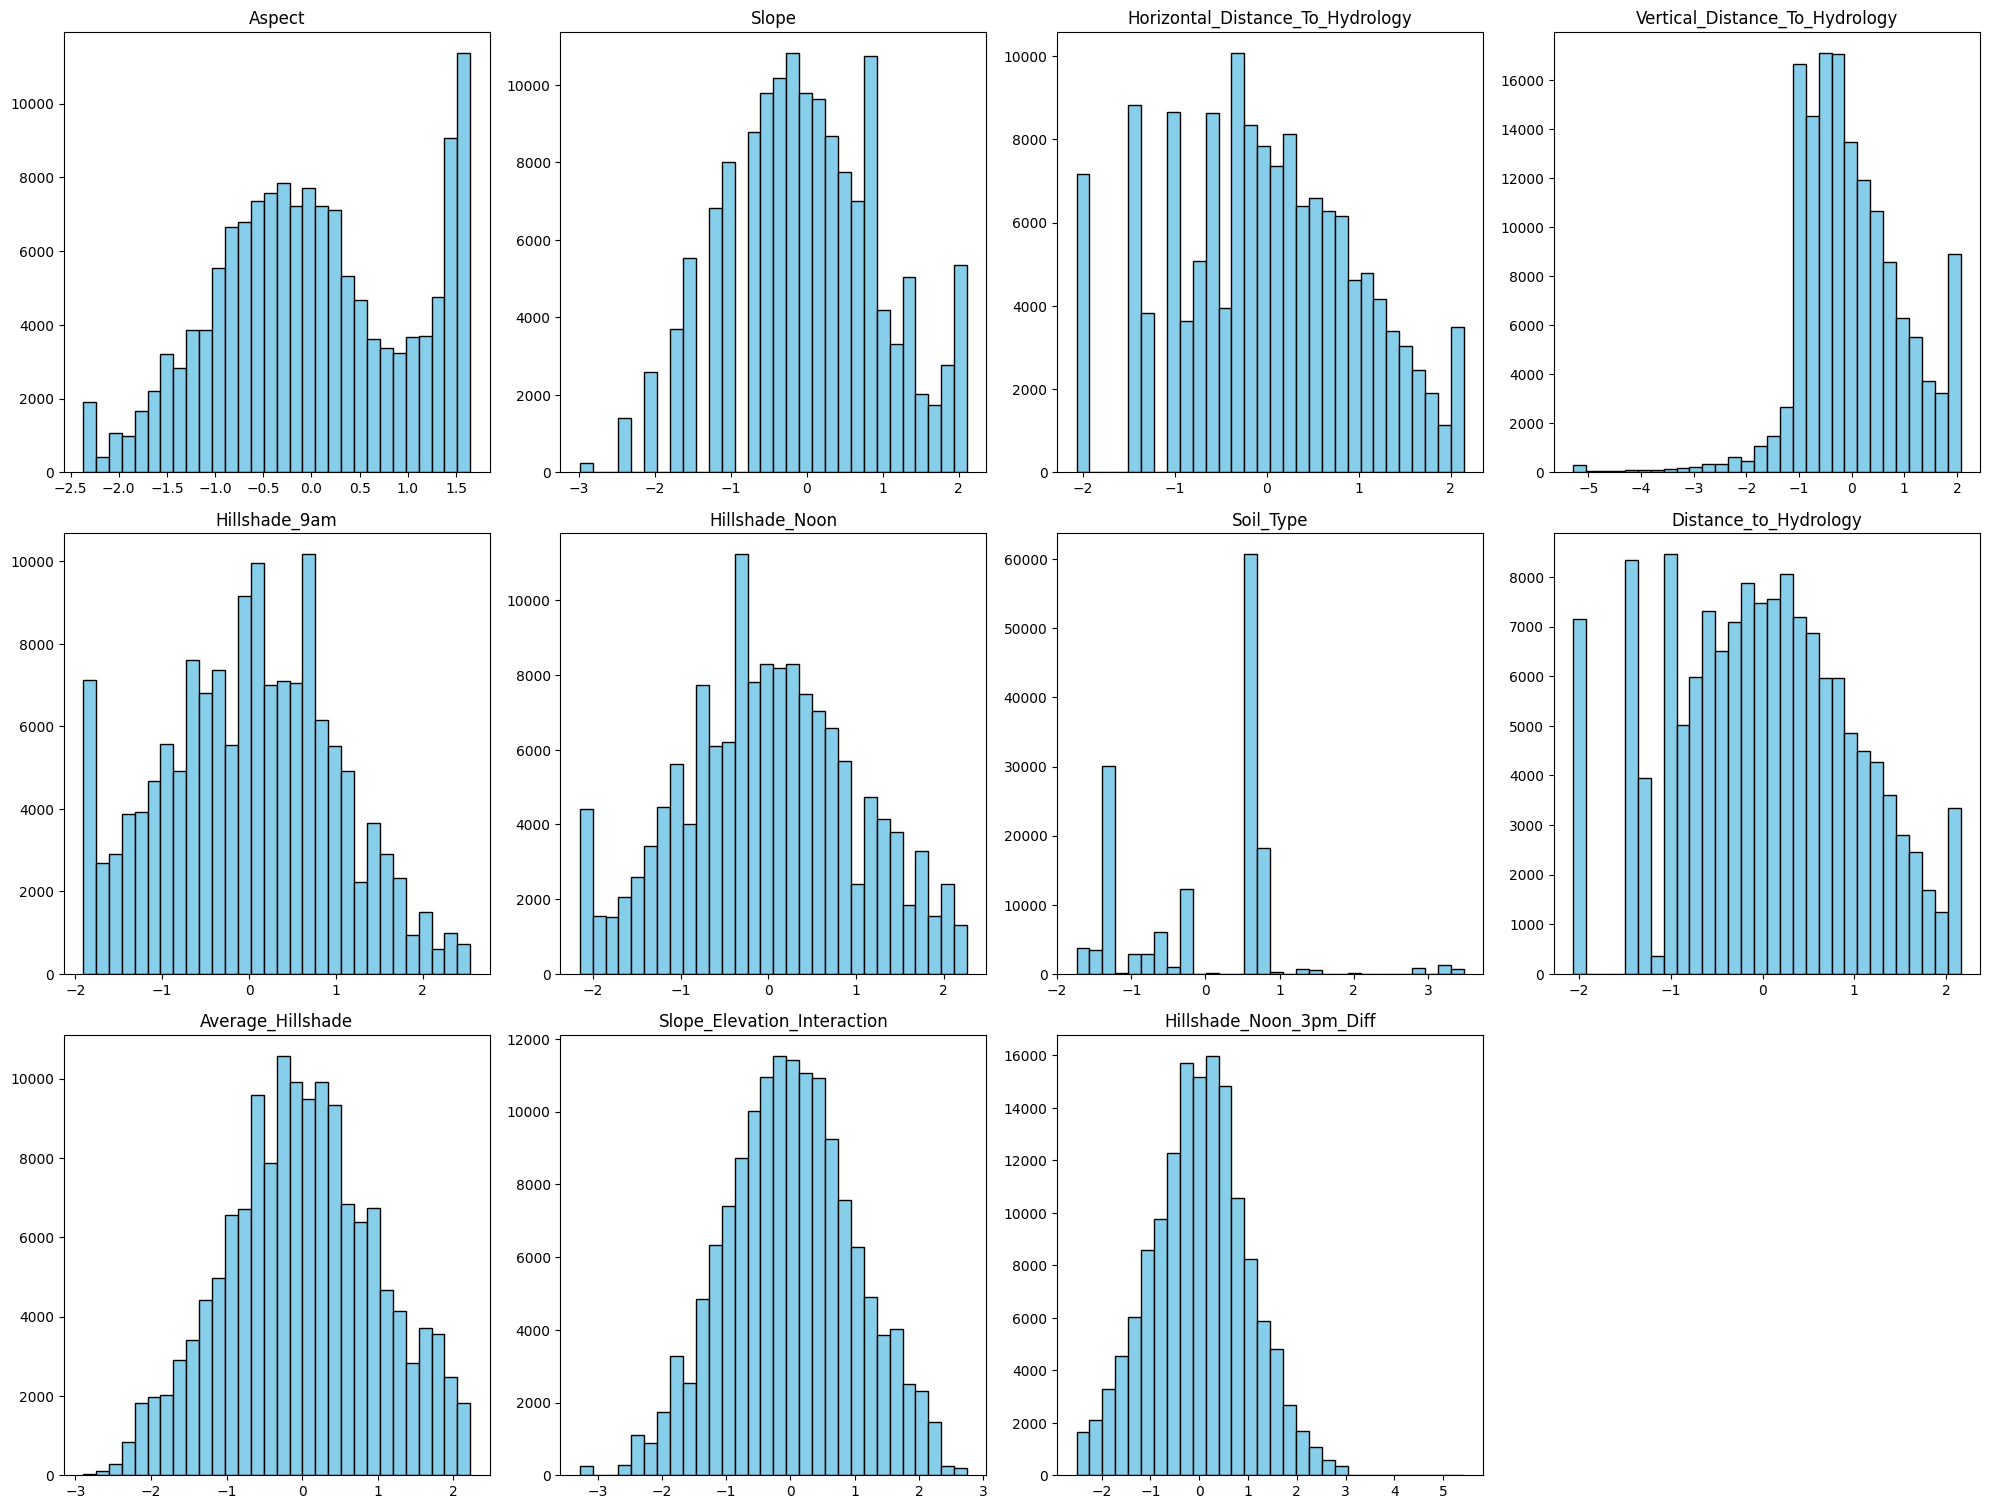

In [ ]:
# Select numerical columns with high skewness (absolute skewness > 0.5)
skewed_cols = skewness[abs(skewness) > 0.5].index

# Plot histograms before transformation
plt.figure(figsize=(20, 30))
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(6, 4, i)  # Adjust grid size as needed
    plt.hist(data[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col}")
plt.tight_layout()
plt.show()



In [ ]:
print(skewed_cols)

Index(['Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Hillshade_9am', 'Hillshade_Noon',
       'Soil_Type', 'Distance_to_Hydrology', 'Average_Hillshade',
       'Slope_Elevation_Interaction', 'Hillshade_Noon_3pm_Diff'],
      dtype='object')


In [ ]:
has_negative = (data.select_dtypes(include=['number']) < 0).any()


print("negative_num_columns:\n")
print(has_negative[has_negative == True])

negative_num_columns:

Aspect                              True
Slope                               True
Horizontal_Distance_To_Hydrology    True
Vertical_Distance_To_Hydrology      True
Hillshade_9am                       True
Hillshade_Noon                      True
Soil_Type                           True
Distance_to_Hydrology               True
Average_Hillshade                   True
Slope_Elevation_Interaction         True
Hillshade_9am_Noon_Diff             True
Hillshade_Noon_3pm_Diff             True
dtype: bool


Apply Yeo-Johnson Power Transformer  to Skewed Columns

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

data[skewed_cols] = pt.fit_transform(data[skewed_cols])

In [ ]:
data[skewed_cols].skew()

,0
Aspect,-0.042728
Slope,-0.011915
Horizontal_Distance_To_Hydrology,-0.005499
Vertical_Distance_To_Hydrology,-0.210297
Hillshade_9am,0.019580
Hillshade_Noon,-0.007164
Soil_Type,0.203636
Distance_to_Hydrology,-0.004617
Average_Hillshade,-0.010386
Slope_Elevation_Interaction,-0.012649


In [ ]:
data.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type', 'Distance_to_Hydrology', 'Average_Hillshade',
       'Hydro_Road_Total', 'Hydro_Fire_Total', 'Road_Fire_Total',
       'Hydro_Road_Diff', 'Elevation_Vertical_Hydro',
       'Slope_Elevation_Interaction', 'Hillshade_9am_Noon_Diff',
       'Hillshade_Noon_3pm_Diff'],
      dtype='object')

Feature importances using Random Forest(Classification)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = data.drop('Cover_Type', axis=1)
y = data['Cover_Type']

# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top features
feature_importance_df

,Feature,Importance
18,Elevation_Vertical_Hydro,0.185556
0,Elevation,0.130371
16,Road_Fire_Total,0.081613
11,Soil_Type,0.075475
9,Horizontal_Distance_To_Fire_Points,0.061157
15,Hydro_Fire_Total,0.060638
14,Hydro_Road_Total,0.059752
5,Horizontal_Distance_To_Roadways,0.057735
17,Hydro_Road_Diff,0.057681
12,Distance_to_Hydrology,0.031313


Bar Graph for Feature Importance

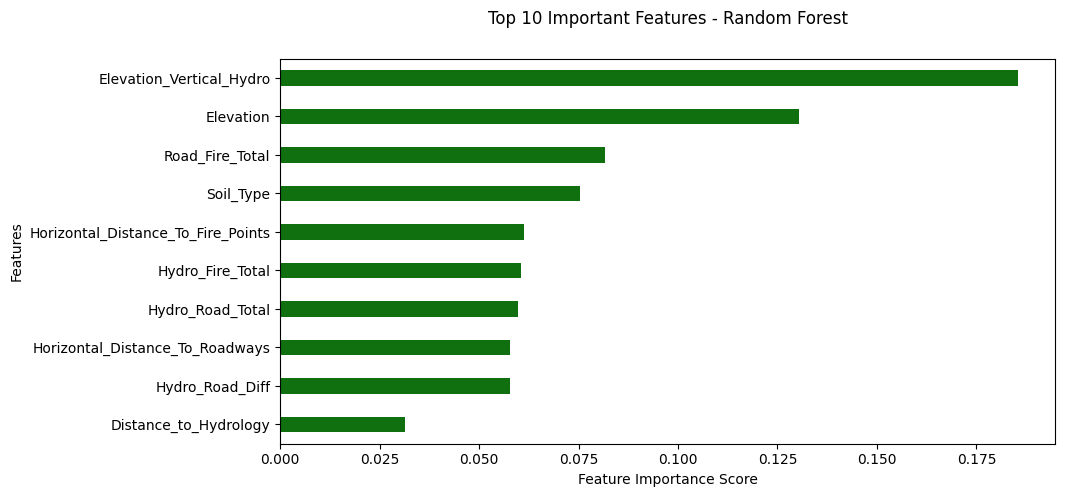

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=feature_importance_df['Importance'][:10], y=feature_importance_df['Feature'][:10], color='green', width=0.4)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest",pad=25)
plt.show()

In [ ]:
# columns to consider

feature_importance_df['Feature'][:10].tolist()

['Elevation_Vertical_Hydro',
 'Elevation',
 'Road_Fire_Total',
 'Soil_Type',
 'Horizontal_Distance_To_Fire_Points',
 'Hydro_Fire_Total',
 'Hydro_Road_Total',
 'Horizontal_Distance_To_Roadways',
 'Hydro_Road_Diff',
 'Distance_to_Hydrology']

In [ ]:
top_10 =['Elevation_Vertical_Hydro',
 'Elevation',
 'Road_Fire_Total',
 'Soil_Type',
 'Horizontal_Distance_To_Fire_Points',
 'Hydro_Fire_Total',
 'Hydro_Road_Total',
 'Horizontal_Distance_To_Roadways',
 'Hydro_Road_Diff',
 'Distance_to_Hydrology']


filtered1 = data[top_10] # original data

filtered1.head()

,Elevation_Vertical_Hydro,Elevation,Road_Fire_Total,Soil_Type,Horizontal_Distance_To_Fire_Points,Hydro_Fire_Total,Hydro_Road_Total,Horizontal_Distance_To_Roadways,Hydro_Road_Diff,Distance_to_Hydrology
0,2596.0,2596.0,6789.0,0.616693,6279.0,6537.0,768.0,510.0,252.0,0.199646
1,2596.0,2590.0,6615.0,0.616693,6225.0,6437.0,602.0,390.0,178.0,-0.036943
2,2739.0,2804.0,9301.0,-1.297641,6121.0,6389.0,3448.0,3180.0,2912.0,0.286665
3,2668.0,2785.0,9301.0,0.821840,6211.0,6453.0,3332.0,3090.0,2848.0,0.252805
4,2596.0,2595.0,6563.0,0.616693,6172.0,6325.0,544.0,391.0,238.0,-0.373956


In [ ]:
filtered1.shape

(145890, 10)

In [ ]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
data['Cover_Type'] = le.fit_transform(data['Cover_Type'])

y = data['Cover_Type']
print(le.classes_)

['Aspen' 'Cottonwood/Willow' 'Douglas-fir' 'Krummholz' 'Lodgepole Pine'
 'Ponderosa Pine' 'Spruce/Fir']


In [ ]:
print(data['Cover_Type'].head(10))

0    0
1    0
2    4
3    4
4    0
5    4
6    0
7    0
8    0
9    0
Name: Cover_Type, dtype: int64


In [ ]:
print(data['Cover_Type'].unique())

[0 4 6 3 5 2 1]


In [ ]:
filtered1['Cover_Type'] = data['Cover_Type']

In [ ]:
filtered1

,Elevation_Vertical_Hydro,Elevation,Road_Fire_Total,Soil_Type,Horizontal_Distance_To_Fire_Points,Hydro_Fire_Total,Hydro_Road_Total,Horizontal_Distance_To_Roadways,Hydro_Road_Diff,Distance_to_Hydrology,Cover_Type
0,2596.0,2596.0,6789.0,0.616693,6279.0,6537.0,768.0,510.0,252.0,0.199646,0
1,2596.0,2590.0,6615.0,0.616693,6225.0,6437.0,602.0,390.0,178.0,-0.036943,0
2,2739.0,2804.0,9301.0,-1.297641,6121.0,6389.0,3448.0,3180.0,2912.0,0.286665,4
3,2668.0,2785.0,9301.0,0.821840,6211.0,6453.0,3332.0,3090.0,2848.0,0.252805,4
4,2596.0,2595.0,6563.0,0.616693,6172.0,6325.0,544.0,391.0,238.0,-0.373956,0
...,...,...,...,...,...,...,...,...,...,...,...
145885,2790.0,2834.0,4147.0,0.616693,1595.0,1971.0,2928.0,2552.0,2176.0,0.751162,4
145886,2788.0,2832.0,4094.0,0.616693,1572.0,1962.0,2912.0,2522.0,2132.0,0.809755,4
145887,2796.0,2829.0,4042.0,0.616693,1550.0,1940.0,2882.0,2492.0,2102.0,0.805235,4
145888,2796.0,2826.0,3990.0,0.616693,1528.0,1907.0,2841.0,2462.0,2083.0,0.758031,4


Standard scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [ ]:
X = filtered1.drop('Cover_Type', axis=1)
y = filtered1['Cover_Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df.head())

   Elevation_Vertical_Hydro  Elevation  Road_Fire_Total  Soil_Type  \
0                 -1.273107  -1.422686         0.155974   0.616693   
1                 -1.273107  -1.452980         0.092891   0.616693   
2                 -0.542612  -0.372506         1.066701  -1.297641   
3                 -0.905305  -0.468436         1.066701   0.821840   
4                 -1.273107  -1.427735         0.074038   0.616693   

   Horizontal_Distance_To_Fire_Points  Hydro_Fire_Total  Hydro_Road_Total  \
0                            1.835567          1.811889         -1.600904   
1                            1.804918          1.756002         -1.695956   
2                            1.745890          1.729176         -0.066318   
3                            1.796972          1.764944         -0.132741   
4                            1.774836          1.693408         -1.729168   

   Horizontal_Distance_To_Roadways  Hydro_Road_Diff  Distance_to_Hydrology  
0                        -1.661258     

In [ ]:
X_scaled_df

,Elevation_Vertical_Hydro,Elevation,Road_Fire_Total,Soil_Type,Horizontal_Distance_To_Fire_Points,Hydro_Fire_Total,Hydro_Road_Total,Horizontal_Distance_To_Roadways,Hydro_Road_Diff,Distance_to_Hydrology
0,-1.273107,-1.422686,0.155974,0.616693,1.835567,1.811889,-1.600904,-1.661258,-1.708151,0.199646
1,-1.273107,-1.452980,0.092891,0.616693,1.804918,1.756002,-1.695956,-1.732357,-1.753091,-0.036943
2,-0.542612,-0.372506,1.066701,-1.297641,1.745890,1.729176,-0.066318,-0.079292,-0.092748,0.286665
3,-0.905305,-0.468436,1.066701,0.821840,1.796972,1.764944,-0.132741,-0.132617,-0.131615,0.252805
4,-1.273107,-1.427735,0.074038,0.616693,1.774836,1.693408,-1.729168,-1.731765,-1.716653,-0.373956
...,...,...,...,...,...,...,...,...,...,...
145885,-0.282086,-0.221037,-0.801884,0.616693,-0.822962,-0.739917,-0.364074,-0.451380,-0.539717,0.751162
145886,-0.292302,-0.231135,-0.821099,0.616693,-0.836017,-0.744946,-0.373235,-0.469155,-0.566438,0.809755
145887,-0.251435,-0.246282,-0.839952,0.616693,-0.848503,-0.757242,-0.390413,-0.486930,-0.584656,0.805235
145888,-0.251435,-0.261429,-0.858804,0.616693,-0.860990,-0.775684,-0.413890,-0.504705,-0.596195,0.758031


In [ ]:
X_scaled_df['Cover_Type'] = data['Cover_Type']

In [ ]:
X_scaled_df

,Elevation_Vertical_Hydro,Elevation,Road_Fire_Total,Soil_Type,Horizontal_Distance_To_Fire_Points,Hydro_Fire_Total,Hydro_Road_Total,Horizontal_Distance_To_Roadways,Hydro_Road_Diff,Distance_to_Hydrology,Cover_Type
0,-1.273107,-1.422686,0.155974,0.616693,1.835567,1.811889,-1.600904,-1.661258,-1.708151,0.199646,0
1,-1.273107,-1.452980,0.092891,0.616693,1.804918,1.756002,-1.695956,-1.732357,-1.753091,-0.036943,0
2,-0.542612,-0.372506,1.066701,-1.297641,1.745890,1.729176,-0.066318,-0.079292,-0.092748,0.286665,4
3,-0.905305,-0.468436,1.066701,0.821840,1.796972,1.764944,-0.132741,-0.132617,-0.131615,0.252805,4
4,-1.273107,-1.427735,0.074038,0.616693,1.774836,1.693408,-1.729168,-1.731765,-1.716653,-0.373956,0
...,...,...,...,...,...,...,...,...,...,...,...
145885,-0.282086,-0.221037,-0.801884,0.616693,-0.822962,-0.739917,-0.364074,-0.451380,-0.539717,0.751162,4
145886,-0.292302,-0.231135,-0.821099,0.616693,-0.836017,-0.744946,-0.373235,-0.469155,-0.566438,0.809755,4
145887,-0.251435,-0.246282,-0.839952,0.616693,-0.848503,-0.757242,-0.390413,-0.486930,-0.584656,0.805235,4
145888,-0.251435,-0.261429,-0.858804,0.616693,-0.860990,-0.775684,-0.413890,-0.504705,-0.596195,0.758031,4


In [ ]:
X_scaled_df.columns


Index(['Elevation_Vertical_Hydro', 'Elevation', 'Road_Fire_Total', 'Soil_Type',
       'Horizontal_Distance_To_Fire_Points', 'Hydro_Fire_Total',
       'Hydro_Road_Total', 'Horizontal_Distance_To_Roadways',
       'Hydro_Road_Diff', 'Distance_to_Hydrology', 'Cover_Type'],
      dtype='object')

Saving the filtered data to drive

In [ ]:
#file_path = r"/content/drive/MyDrive/cleaned_data.csv"
#X_scaled_df.to_csv(file_path, index=False)

In [ ]:
X_scaled_df.to_csv("cleaned_data2.csv",index = False)

In [ ]:
import pickle

In [ ]:
with open('my_data2.pkl', 'wb') as file:
    pickle.dump(data, file)

print("data saved succesfully")

data saved succesfully
